In [1]:
from dolfinx.fem import functionspace, Function
from dolfinx import mesh
from geometry_class import Geometry
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np
from parametrizations import Parameter
from visualization_fct import get_grid, eval_fct_on_grid, plotScalarFunction

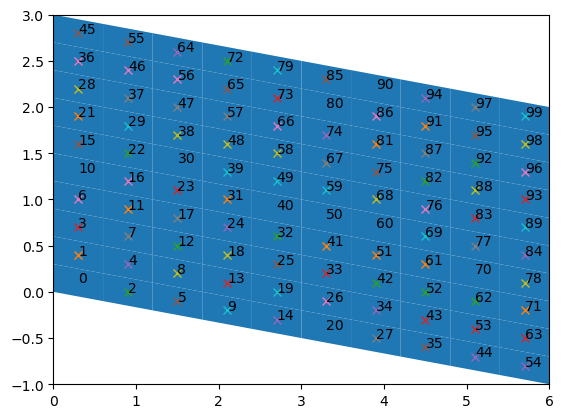

In [2]:
geom = Geometry(3, 6, -1/6)
msh = Geometry.make_domain(geom, 10, 10)
[P0, P1, P2, P3] = geom.corner_points
p = Parameter(msh)
tdim = msh.topology.dim
c2v = msh.topology.connectivity(tdim, 0)
num_cells = msh.topology.index_map(tdim).size_local
cells = np.arange(num_cells, dtype=np.int32)
midpoints = mesh.compute_midpoints(msh, tdim, cells)
x = msh.geometry.x
fig, ax = plt.subplots(1,1)
ax.set_xlim(0, 6)
ax.set_ylim(-1, 3)
for cell, coord in enumerate(midpoints):
    vertices = x[c2v.links(cell)][:,:2]
    polygon = Polygon(np.vstack([vertices[:2], vertices[3], vertices[2]]), closed=False)
    ax.add_patch(polygon)
    ax.plot(coord[0], coord[1], 'x')
    ax.annotate(cell, (coord[0], coord[1]))


2026-07-02 15:08:56.397 (   0.458s) [    72CEB38F8600]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


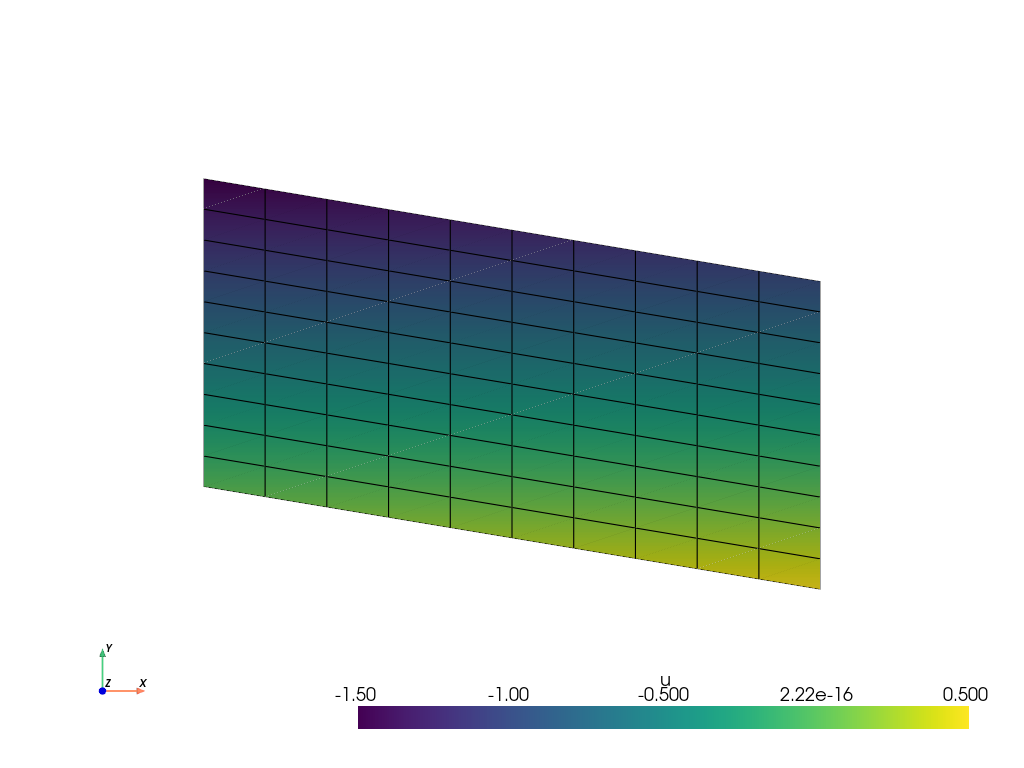

In [3]:
W = functionspace(msh, ("CG", 1))
hw = Function(W)
def ini(x):
    return -0.5*x[1]
hw.interpolate(ini)
plotScalarFunction(W, hw)

h_tot=[-6.9388939e-18  1.5000000e-01 -5.0000000e-02  1.0000000e-01], z=[ 0.   0.3 -0.1  0.2], argmax=1
h_tot=[0.15 0.3  0.1  0.25], z=[0.3 0.6 0.2 0.5], argmax=1
h_tot=[-0.05  0.1  -0.1   0.05], z=[-0.1  0.2 -0.2  0.1], argmax=1
h_tot=[0.3  0.45 0.25 0.4 ], z=[0.6 0.9 0.5 0.8], argmax=1
h_tot=[0.1  0.25 0.05 0.2 ], z=[0.2 0.5 0.1 0.4], argmax=1
h_tot=[-1.00000000e-01  5.00000000e-02 -1.50000000e-01 -6.24500451e-17], z=[-2.00000000e-01  1.00000000e-01 -3.00000000e-01 -1.11022302e-16], argmax=1
h_tot=[0.45 0.6  0.4  0.55], z=[0.9 1.2 0.8 1.1], argmax=1
h_tot=[0.25 0.4  0.2  0.35], z=[0.5 0.8 0.4 0.7], argmax=1
h_tot=[ 5.00000000e-02  2.00000000e-01 -6.24500451e-17  1.50000000e-01], z=[ 1.00000000e-01  4.00000000e-01 -1.11022302e-16  3.00000000e-01], argmax=1
h_tot=[-1.50000000e-01 -6.24500451e-17 -2.00000000e-01 -5.00000000e-02], z=[-3.00000000e-01 -1.11022302e-16 -4.00000000e-01 -1.00000000e-01], argmax=1
h_tot=[0.6  0.75 0.55 0.7 ], z=[1.2 1.5 1.1 1.4], argmax=1
h_tot=[0.4  0.55 0.35 0

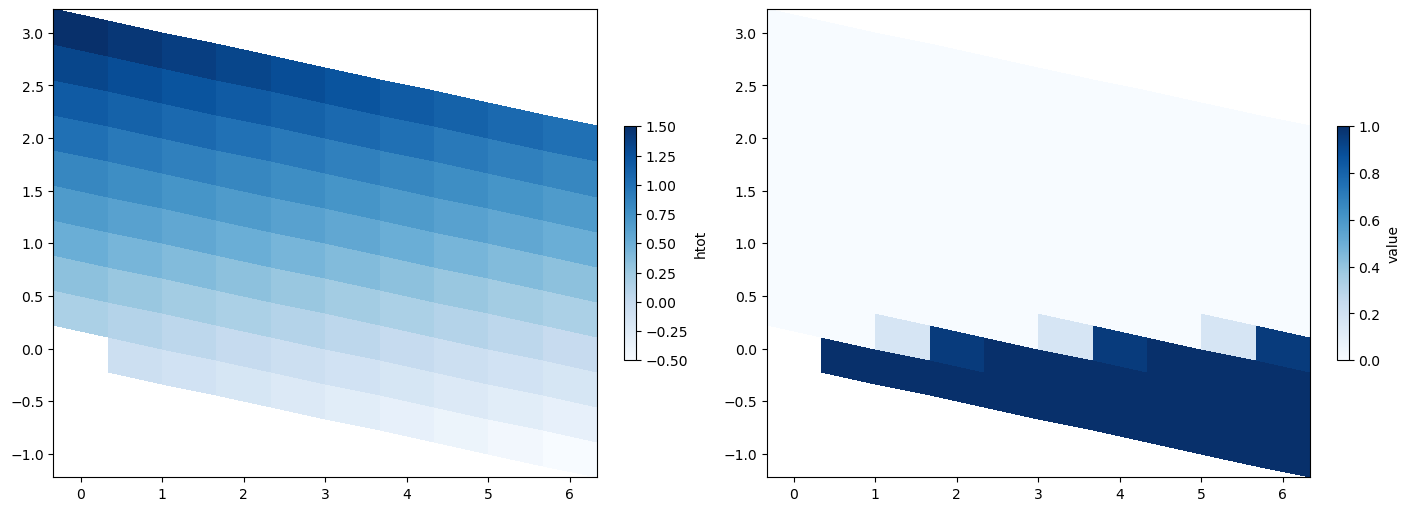

In [4]:
grid, x_plot, z_plot = get_grid(P0, P1, P2, P3, nx=10, nz=10)
h_w = eval_fct_on_grid(grid, hw, msh).reshape((10,10))
h_tot = h_w + z_plot
krel = p.upwind_krel(hw, msh)

krel_eval = eval_fct_on_grid(grid, krel, msh).reshape((10,10))

fig, ax = plt.subplots(1,2, layout="constrained", figsize=(14,5))
pmsh1 = ax[0].pcolormesh(x_plot, z_plot, h_tot, cmap="Blues")
cbar1 = fig.colorbar(pmsh1, ax=ax[0], shrink=0.5)
cbar1.set_label("htot")

pmsh2 = ax[1].pcolormesh(x_plot, z_plot, krel_eval, cmap="Blues")
cbar2 = fig.colorbar(pmsh2, ax=ax[1], shrink=0.5)
cbar2.set_label("value")

In [7]:
np.all(np.isclose(W.tabulate_dof_coordinates(),msh.geometry.x))

np.True_

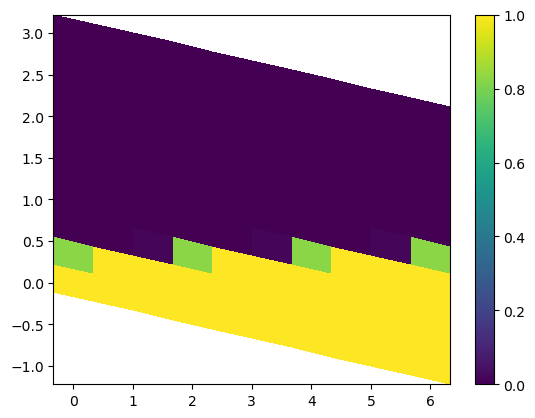

In [16]:
k = np.zeros_like(h_w)
for i in range(h_w.shape[0]):
    for j in range(h_w.shape[1]):
        k[i,j] = p.calc_krel(h_w[i,j], p.alpha.value, p.N.value)

plt.pcolormesh(x_plot, z_plot, k)
plt.colorbar()

In [17]:
k

array([[1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 1.00000000e+00],
       [8.26891976e-01, 9.99246170e-01, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 1.00000000e+00],
       [1.03414536e-08, 7.05421830e-06, 1.33503557e-02, 8.26891976e-01,
        9.99246170e-01, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 1.00000000e+00],
       [4.94701082e-15, 3.39216828e-13, 4.09323007e-11, 1.03414536e-08,
        7.05421830e-06, 1.33503557e-02, 8.26891976e-01, 9.99246170e-01,
        1.00000000e+00, 1.00000000e+00],
       [1.62036658e-19, 3.68171647e-18, 1.12683111e-16, 4.94701082e-15,
        3.39216828e-13, 4.09323007e-11, 1.03414536e-08, 7.05421830e-06,
        1.33503557e-02, 8.26891976e-01],
       [5.38251770e-23, 6.40513999e-22, 9.15824160e-21, 1.62036658e-19,
   